In [64]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
df = pd.read_excel('Data_Train.xlsx')

In [67]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [68]:
df.shape

(10683, 11)

In [69]:
df.duplicated().sum()

np.int64(220)

In [70]:
df.drop_duplicates(inplace=True)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10463 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10463 non-null  object
 1   Date_of_Journey  10463 non-null  object
 2   Source           10463 non-null  object
 3   Destination      10463 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10463 non-null  object
 6   Arrival_Time     10463 non-null  object
 7   Duration         10463 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10463 non-null  object
 10  Price            10463 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.9+ KB


In [72]:
df.describe()

,Price
count,10463.000000
mean,9026.642454
std,4624.653227
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12343.500000
max,79512.000000


In [73]:
df['Additional_Info'].nunique()

10

<Axes: >

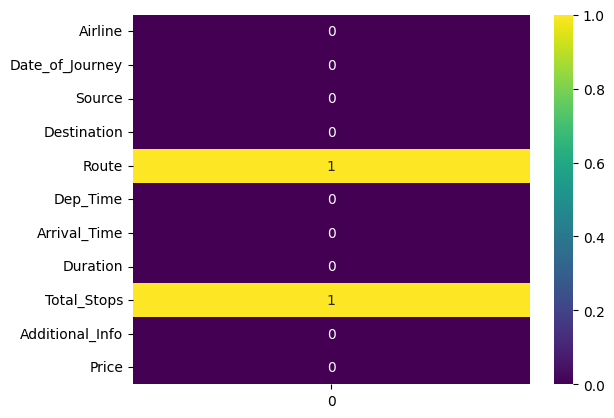

In [74]:
sns.heatmap(df.isna().sum().to_frame(), annot=True, cmap='viridis')

In [75]:
df.sample(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
2994,Air India,24/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,07:40 25 Mar,27h 40m,1 stop,No info,8635
3463,IndiGo,09/03/2019,Banglore,New Delhi,BLR → IDR → DEL,17:55,22:55,5h,1 stop,No info,6351
2676,Air India,21/05/2019,Kolkata,Banglore,CCU → DEL → BLR,10:00,23:15,13h 15m,1 stop,No info,11936
4283,Jet Airways,21/05/2019,Banglore,Delhi,BLR → DEL,06:00,08:45,2h 45m,non-stop,In-flight meal not included,4030
6393,Jet Airways,15/05/2019,Kolkata,Banglore,CCU → DEL → BLR,17:00,21:05 16 May,28h 5m,1 stop,No info,14151


# **Univariate Analysis**

# Airline

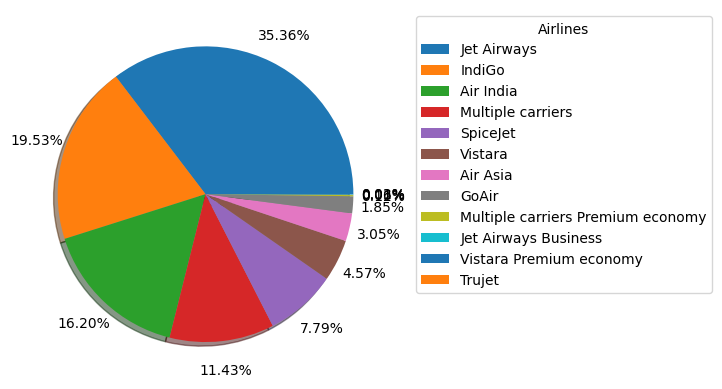

In [76]:
wedges, texts, autotexts = plt.pie(df['Airline'].value_counts(),
                                   autopct='%1.2f%%',
                                   shadow=True,
                                   pctdistance=1.2)
plt.legend(wedges, df['Airline'].value_counts().index, title="Airlines", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

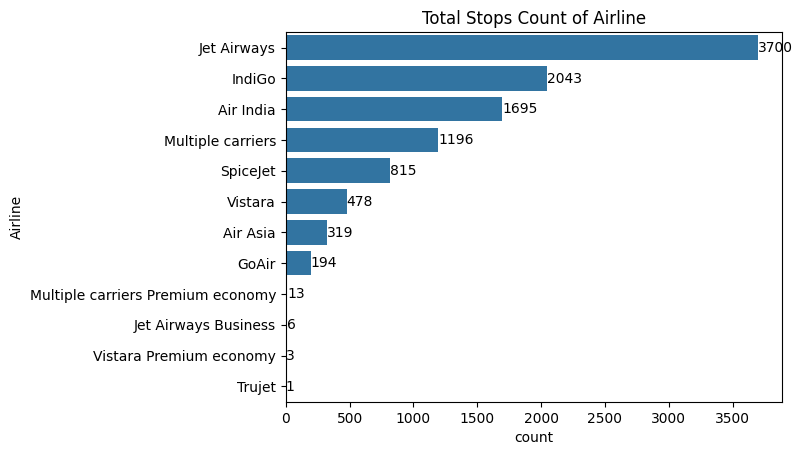

In [77]:
ax = sns.countplot(y=df['Airline'], order=df['Airline'].value_counts().index)
ax.bar_label(ax.containers[0])
plt.title("Total Stops Count of Airline")
plt.show()

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10463 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10463 non-null  object
 1   Date_of_Journey  10463 non-null  object
 2   Source           10463 non-null  object
 3   Destination      10463 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10463 non-null  object
 6   Arrival_Time     10463 non-null  object
 7   Duration         10463 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10463 non-null  object
 10  Price            10463 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.9+ KB


In [79]:
df['Total_Stops'] = df['Total_Stops'].str.replace('stops','').str.replace('stop','').str.replace('non-','0').str.strip()
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302


In [80]:
df['Total_Stops'].mode()

,Total_Stops
0,1


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10463 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10463 non-null  object
 1   Date_of_Journey  10463 non-null  object
 2   Source           10463 non-null  object
 3   Destination      10463 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10463 non-null  object
 6   Arrival_Time     10463 non-null  object
 7   Duration         10463 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10463 non-null  object
 10  Price            10463 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1.2+ MB


# Preprocessing

In [82]:
df['Additional_Info'] = df['Additional_Info'].replace('No info','No Info')

In [83]:
df.loc[(df['Airline'] == 'Jet Airways Business') & (df['Additional_Info'] == 'No Info'), 'Additional_Info'] = 'Business class'
df[df['Airline'] == 'Jet Airways Business']

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
657,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,05:45,10:45,5h,1,Business class,52229
2924,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,05:45,11:25,5h 40m,1,Business class,79512
5372,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,05:45,12:25,6h 40m,1,Business class,62427
7351,Jet Airways Business,3/03/2019,Delhi,Cochin,DEL → ATQ → BOM → COK,20:05,04:25 04 Mar,8h 20m,2,Business class,46490
9715,Jet Airways Business,6/03/2019,Delhi,Cochin,DEL → ATQ → BOM → COK,20:05,04:25 07 Mar,8h 20m,2,Business class,52285
10364,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → MAA → DEL,09:45,14:25,4h 40m,1,Business class,57209


# Total Stops

---
* There are Half of the people who traveled direct to their destination without any Stops/ Stoppages

In [84]:
df['Total_Stops'].isna().sum()

np.int64(1)

In [85]:
df[df['Total_Stops'].isna()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No Info,7480


In [86]:
df.groupby(df['Airline'] == 'Air India')['Total_Stops'].value_counts()

Airline  Total_Stops
False    1              5085
         0              3059
         2               616
         3                 8
True     2               702
         1               540
         0               416
         3                35
         4                 1
Name: count, dtype: int64

In [87]:
df[df['Route'].isna()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No Info,7480


In [88]:
df.dropna(inplace=True)

In [89]:
df['Total_Stops'].fillna(df['Total_Stops'].mode()[0], inplace=True)

/tmp/ipykernel_23378/3351361124.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total_Stops'].fillna(df['Total_Stops'].mode()[0], inplace=True)


In [90]:
df['Total_Stops'] = df['Total_Stops'].astype('int64')

In [91]:
df['Total_Stops'].value_counts().sort_index(ascending=True)

,count
Total_Stops,
0,3475
1,5625
2,1318
3,43
4,1


# **Exploratory Data Analysis**

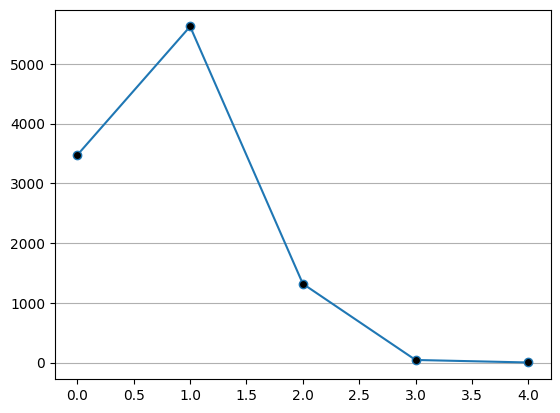

In [92]:
plt.plot(df['Total_Stops'].value_counts().sort_index(ascending=True), marker = 'o', markerfacecolor='black')
plt.grid(axis='y')

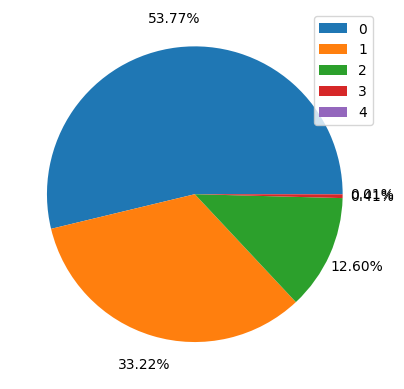

In [93]:
wedges, texts, autotexts = plt.pie(df['Total_Stops'].value_counts(), autopct='%1.2f%%', pctdistance=1.2)
plt.legend(wedges, df['Total_Stops'].value_counts().sort_index(ascending=True).index)
plt.show()

# Price
---
* 98% of people Travels Flights which prices are under 18383.48 USD

/tmp/ipykernel_23378/2868737299.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Price', data=df[df['Price'] < 25000], palette = 'Greens', )


<Axes: xlabel='Price'>

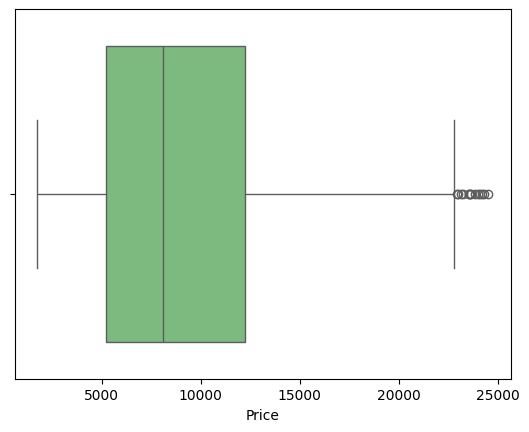

In [94]:
sns.boxplot(x = 'Price', data=df[df['Price'] < 25000], palette = 'Greens', )

/tmp/ipykernel_23378/2928668524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df['Price'], palette = 'Greens')


<Axes: xlabel='Price'>

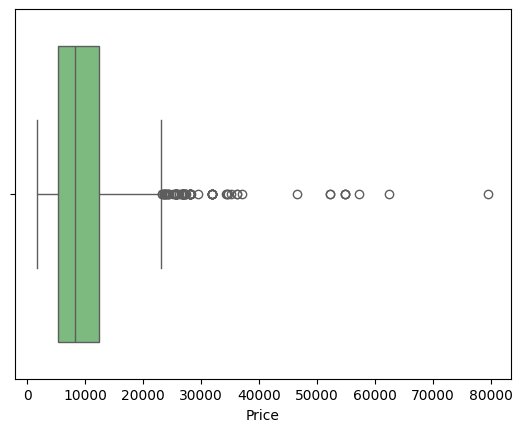

In [95]:
sns.boxplot(x = df['Price'], palette = 'Greens')

# Source

In [96]:
df.sample(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
2112,Jet Airways,21/05/2019,Kolkata,Banglore,CCU → GAU → BLR,10:20,17:35,7h 15m,1,No Info,8355
4909,SpiceJet,1/03/2019,Mumbai,Hyderabad,BOM → HYD,22:45,00:10 02 Mar,1h 25m,0,No Info,11005
10642,Air India,21/05/2019,Kolkata,Banglore,CCU → JAI → BOM → BLR,08:20,11:10 22 May,26h 50m,2,No Info,11222
1673,Jet Airways,12/06/2019,Kolkata,Banglore,CCU → BOM → BLR,06:30,16:20,9h 50m,1,In-flight meal not included,9899
6928,Jet Airways,12/06/2019,Delhi,Cochin,DEL → BOM → COK,09:00,12:35 13 Jun,27h 35m,1,In-flight meal not included,10262


([<matplotlib.patches.Wedge at 0x7c3bc43fae70>,
 [Text(0.28921832033333006, 1.061297678874107, 'Delhi'),
  Text(-1.0418131246308335, -0.3530232476012583, 'Kolkata'),
  Text(0.29240402225907547, -1.0604243904054236, 'Banglore'),
  Text(0.9961073819141538, -0.4666584229349453, 'Mumbai'),
  Text(1.0928086944665096, -0.12557530528890998, 'Chennai')],
 [Text(0.15775544745454365, 0.5788896430222402, '41.53%'),
  Text(-0.568261704344091, -0.19255813505523178, '27.34%'),
  Text(0.1594931030504048, -0.5784133038575038, '20.83%'),
  Text(0.5433312992259021, -0.2545409579645156, '6.66%'),
  Text(0.5960774697090052, -0.06849562106667817, '3.64%')])

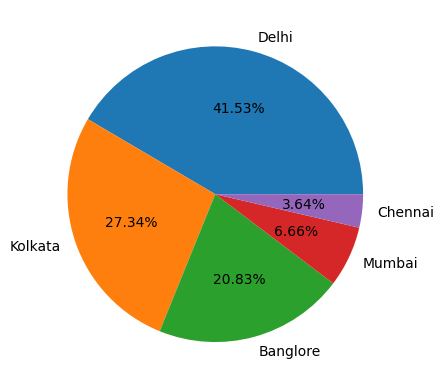

In [97]:
plt.pie(df['Source'].value_counts(),
        labels = df['Source'].value_counts().index,
        autopct = '%1.2f%%')

In [98]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No Info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No Info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No Info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No Info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No Info,13302


<Axes: xlabel='Source', ylabel='count'>

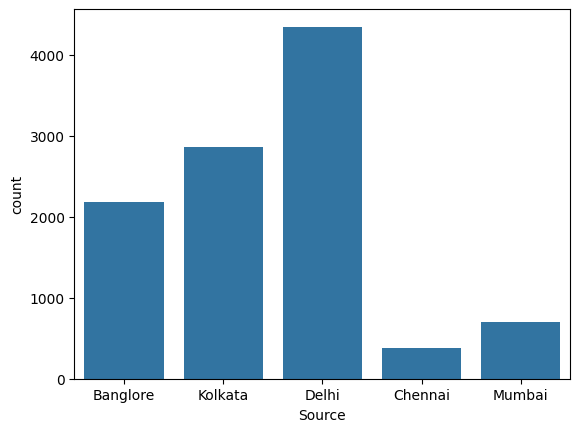

In [99]:
sns.countplot(x = df['Source'])

<Axes: xlabel='Destination', ylabel='Count'>

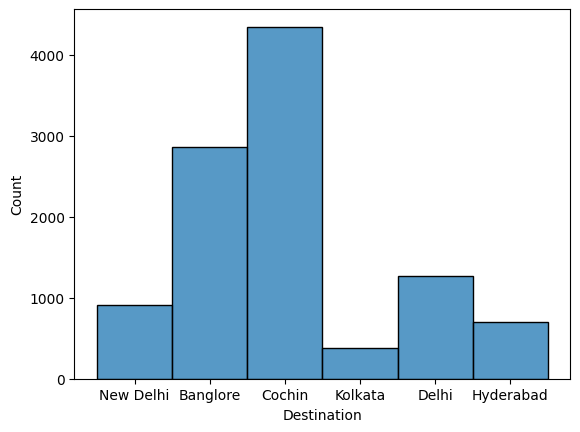

In [100]:
sns.histplot(df['Destination'])

In [101]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No Info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No Info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No Info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No Info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No Info,13302


In [102]:
temp = pd.read_excel('Data_Train.xlsx', usecols=['Airline', 'Source', 'Destination', 'Total_Stops'])

In [103]:
temp.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops'], dtype='object')

/tmp/ipykernel_23378/567101540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=i, data=temp, palette = 'PuRd')


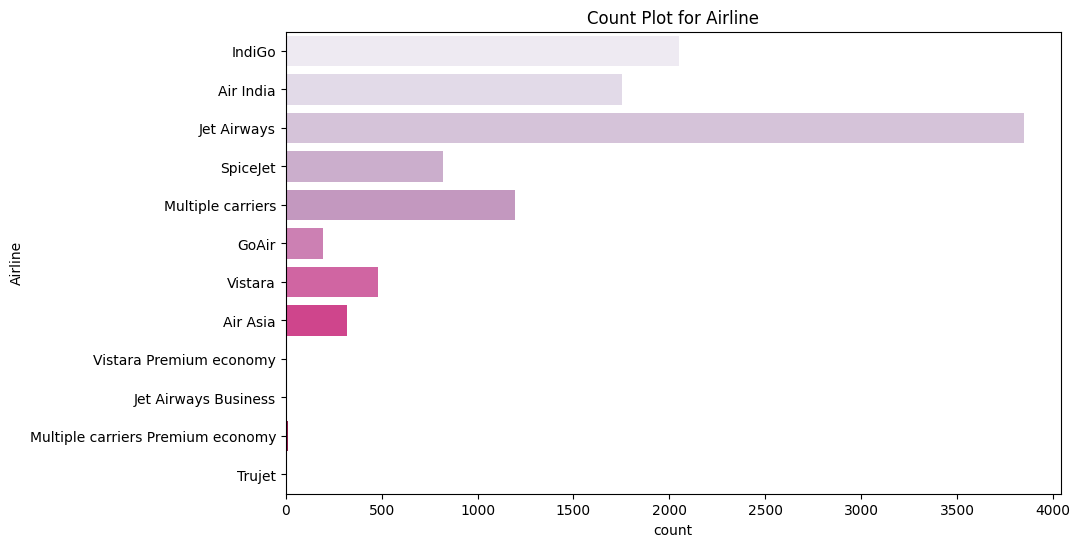

/tmp/ipykernel_23378/567101540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=i, data=temp, palette = 'PuRd')


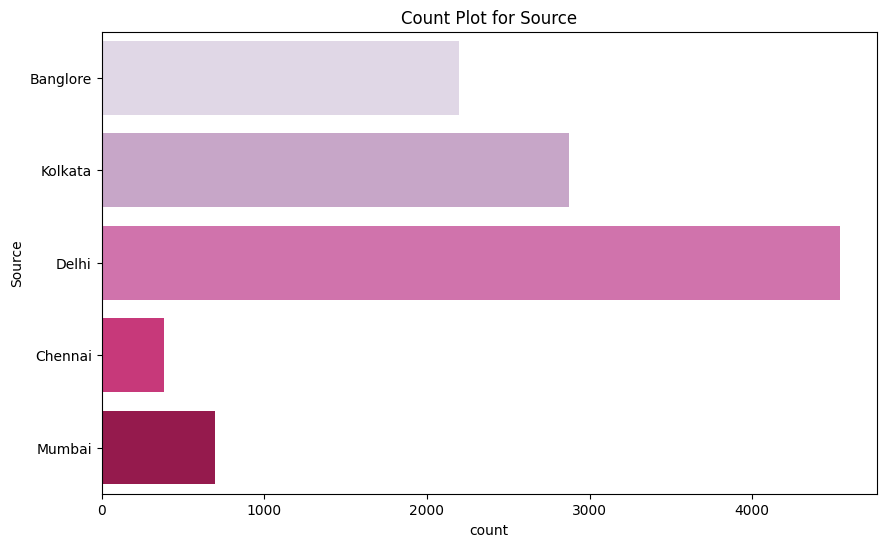

/tmp/ipykernel_23378/567101540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=i, data=temp, palette = 'PuRd')


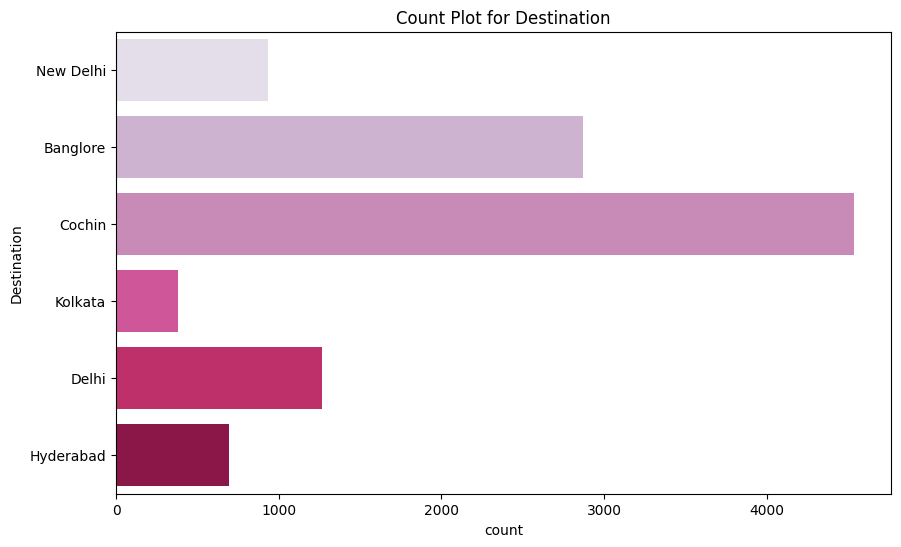

/tmp/ipykernel_23378/567101540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=i, data=temp, palette = 'PuRd')


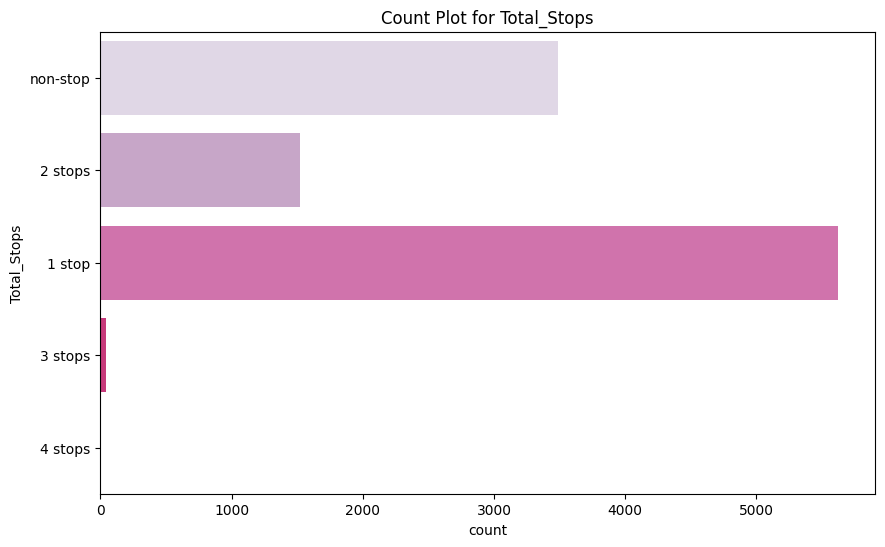

In [104]:
for i in temp.columns:
  plt.figure(figsize=(10, 6))
  sns.countplot(y=i, data=temp, palette = 'PuRd')
  plt.title(f'Count Plot for {i}')
  plt.show()

# **Multivariate Analysis**

# Total_Stops vs Price
---
* The 97.9% of price data falls between 1759.00 and 18383.48
* Mostly flights are directly goes to their destination without any stoppages and are Cheaper than others
* Price is highly correlated with Total_Stops (60%)

In [105]:
map = df[['Price','Total_Stops']].corr()
map

,Price,Total_Stops
Price,1.000000,0.602013
Total_Stops,0.602013,1.000000


<Axes: >

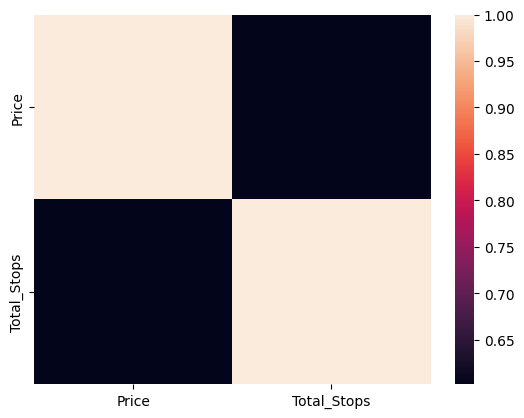

In [106]:
sns.heatmap(map)

In [107]:
df.describe()

,Total_Stops,Price
count,10462.000000,10462.000000
mean,0.802332,9026.790289
std,0.660609,4624.849541
min,0.000000,1759.000000
25%,0.000000,5224.000000
50%,1.000000,8266.000000
75%,1.000000,12344.750000
max,4.000000,79512.000000


In [108]:
lower_bound = df['Price'].quantile(0.0)
upper_bound = df['Price'].quantile(0.98)

percentage = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]['Price'].count() / len(df)

print(f"The 97.9% of price data falls between {lower_bound:.2f} and {upper_bound:.2f}. Percentage is {percentage}")

The 97.9% of price data falls between 1759.00 and 18383.48. Percentage is 0.9799273561460524


<Axes: xlabel='Price', ylabel='Count'>

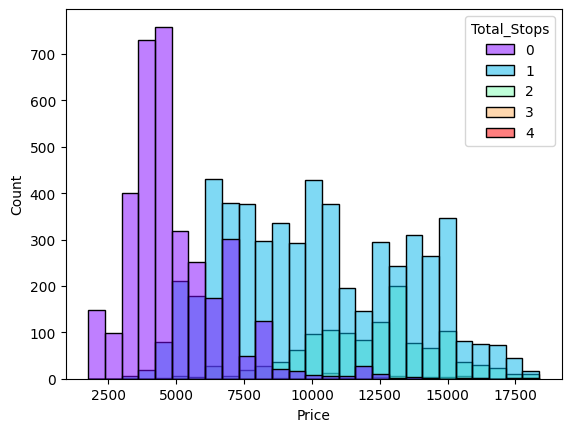

In [109]:
sns.histplot(x='Price', hue='Total_Stops', data=df[df['Price'] < upper_bound], palette='rainbow')

In [110]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No Info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No Info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No Info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No Info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No Info,13302


/tmp/ipykernel_23378/3855263805.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'], kde=True)


<Axes: xlabel='Price', ylabel='Density'>

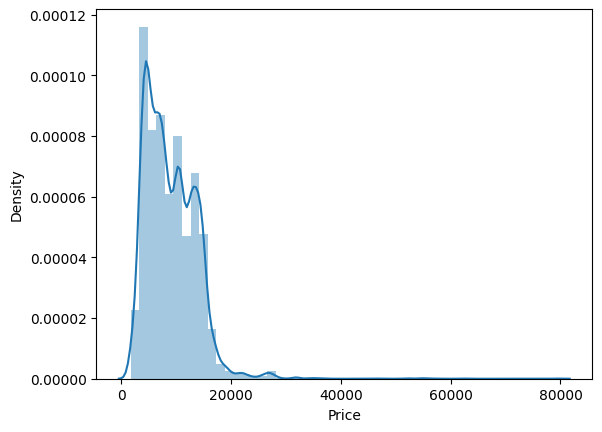

In [111]:
sns.distplot(df['Price'], kde=True)

<Axes: xlabel='Price', ylabel='Count'>

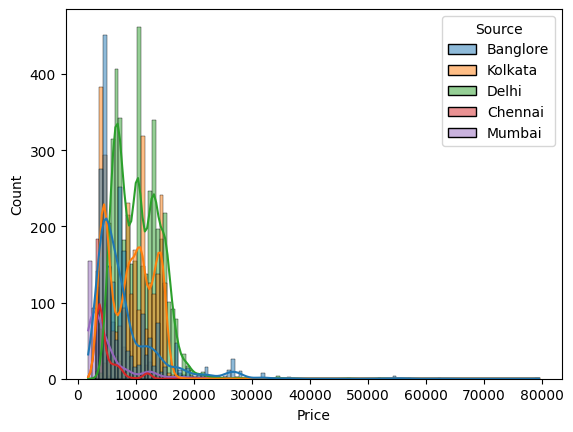

In [112]:
sns.histplot(x = 'Price', data= df , hue = 'Source', kde=True)

# Source-Destination:
---
* Most of Flights are from Delhi to Coachin
* Very few Airplanes goes Chennai to Kolkata

<Axes: xlabel='Destination', ylabel='Count'>

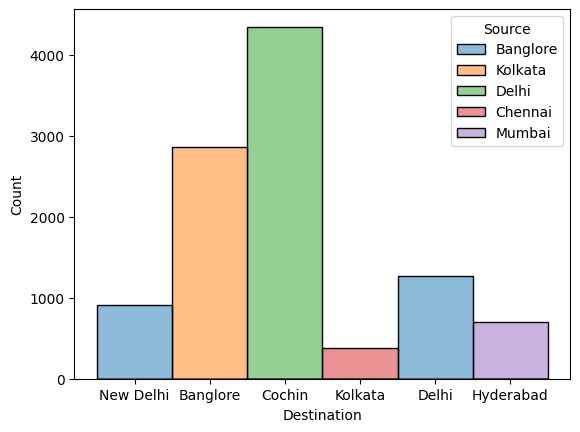

In [113]:
sns.histplot(data = df, x = 'Destination', hue = 'Source')

In [114]:
df[df['Price'] < 20000].count()

,0
Airline,10314
Date_of_Journey,10314
Source,10314
Destination,10314
Route,10314
Dep_Time,10314
Arrival_Time,10314
Duration,10314
Total_Stops,10314
Additional_Info,10314


<Axes: xlabel='Destination', ylabel='Count'>

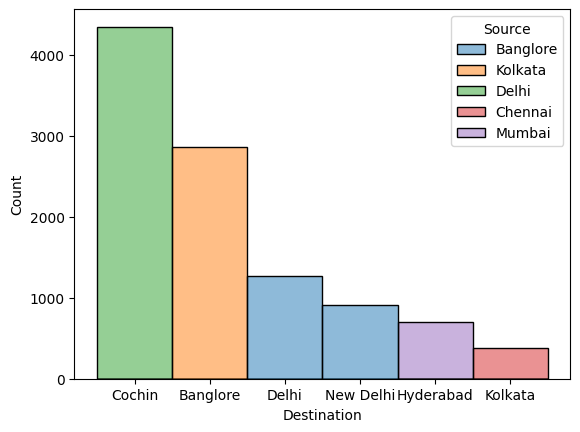

In [115]:
# Get the order of destinations by count (for 'exponent-like' graph)
destination_order = df['Destination'].value_counts().index

# Convert 'Destination' column to a categorical type with the specified order
df['Destination'] = pd.Categorical(df['Destination'], categories=destination_order, ordered=True)

# Now plot using histplot. The order is now inherent in the column itself.
sns.histplot(data=df, x = 'Destination', hue = 'Source')

In [116]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No Info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No Info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No Info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No Info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No Info,13302


([0, 1, 2, 3, 4],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4')])

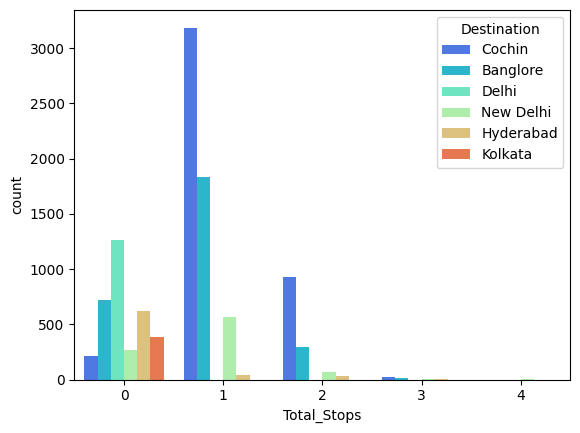

In [117]:
sns.countplot(x = 'Total_Stops', data=df, hue= 'Destination', palette = 'rainbow')
plt.xticks()

Total_Stops-Destination
---
* Airplane which destination is Coachin has Mostly only 1 stoppage
* Very less flights have 4 stops

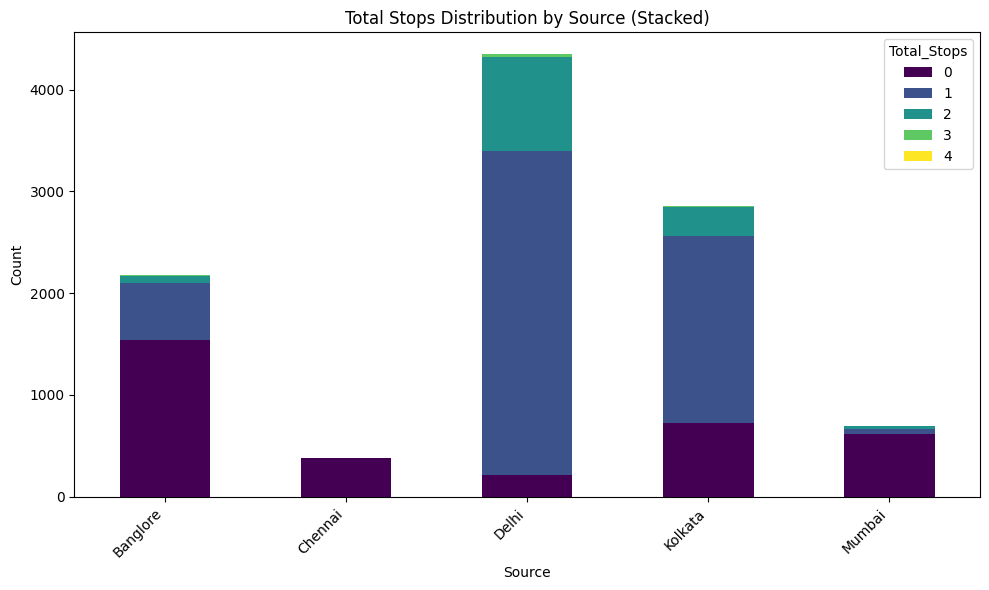

In [118]:
grouped_data = df.groupby(['Source', 'Total_Stops']).size().unstack(fill_value=0)

grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Total Stops Distribution by Source (Stacked)')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total_Stops')
plt.tight_layout()
plt.show()

# Total_Stops vs Source
---
* Departure from Delhi then Kolkata with 1 Stoppage is Higher than others
* Chennai has almost completely departure of flights with 0 stops

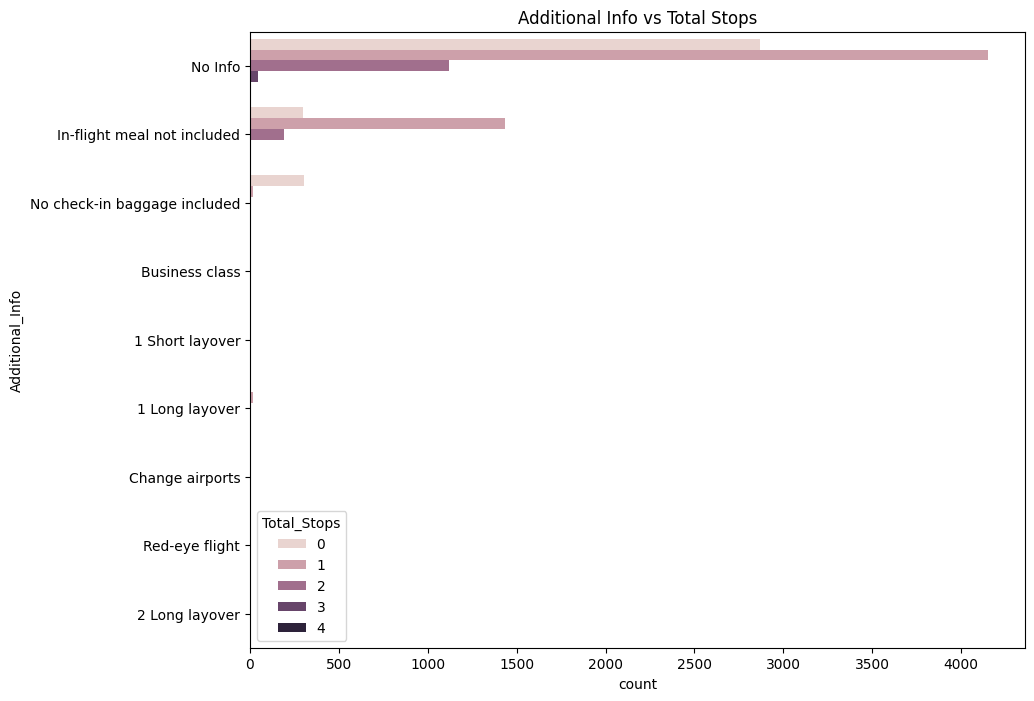

In [119]:
plt.figure(figsize=(10,8))
sns.countplot(y = 'Additional_Info' ,data =df, hue = 'Total_Stops')
plt.title('Additional Info vs Total Stops')
plt.show()

Additional_Info-Total_Stops
---
* Most of the Flights which stoppage is 1,2 and 0 Comparatively has No Info

/tmp/ipykernel_23378/2480072199.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=airline_mean_prices.values, y=airline_mean_prices.index, palette='viridis')


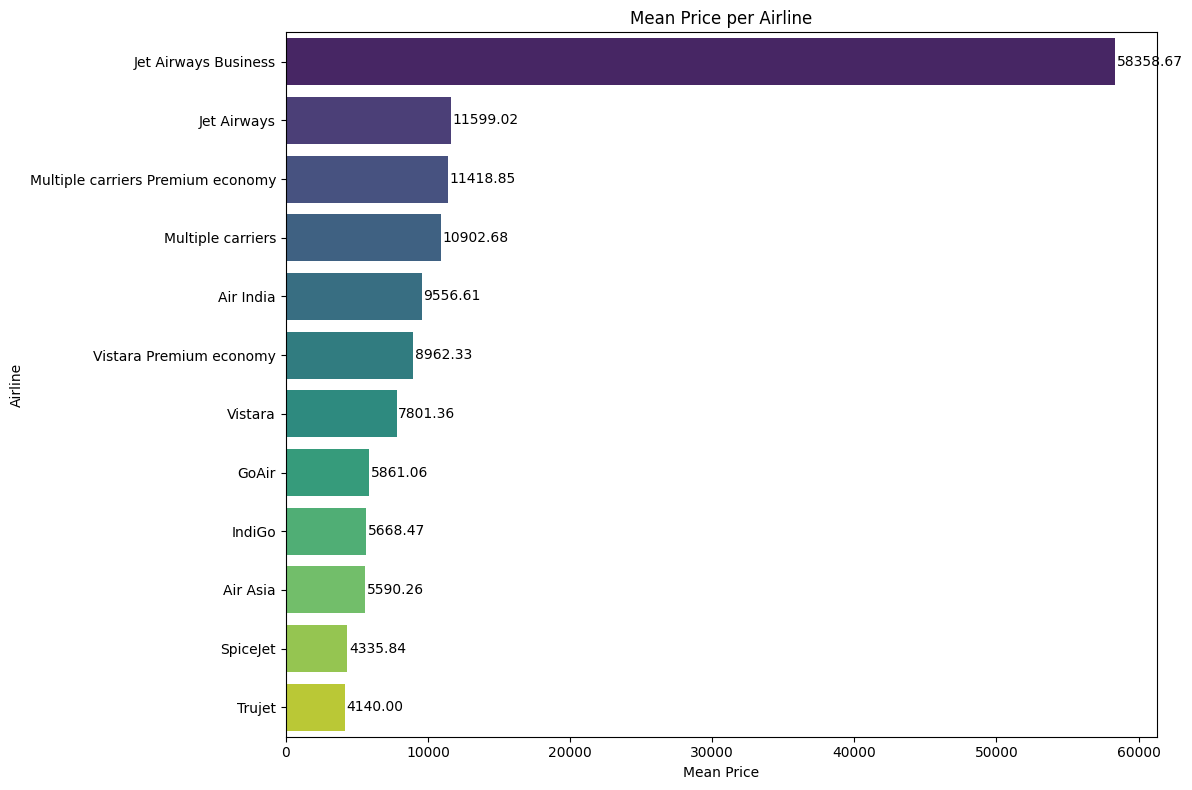

In [120]:
airline_mean_prices = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=airline_mean_prices.values, y=airline_mean_prices.index, palette='viridis')

plt.title('Mean Price per Airline')
plt.xlabel('Mean Price')
plt.ylabel('Airline')

# Add labels to the bars
for index, value in enumerate(airline_mean_prices.values):
    ax.text(value + 100, index, f'{value:.2f}', color='black', ha="left", va="center")

plt.tight_layout()
plt.show()

In [121]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No Info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No Info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No Info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No Info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No Info,13302


/tmp/ipykernel_23378/3749432221.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby([i, j]).size().unstack(fill_value=0)


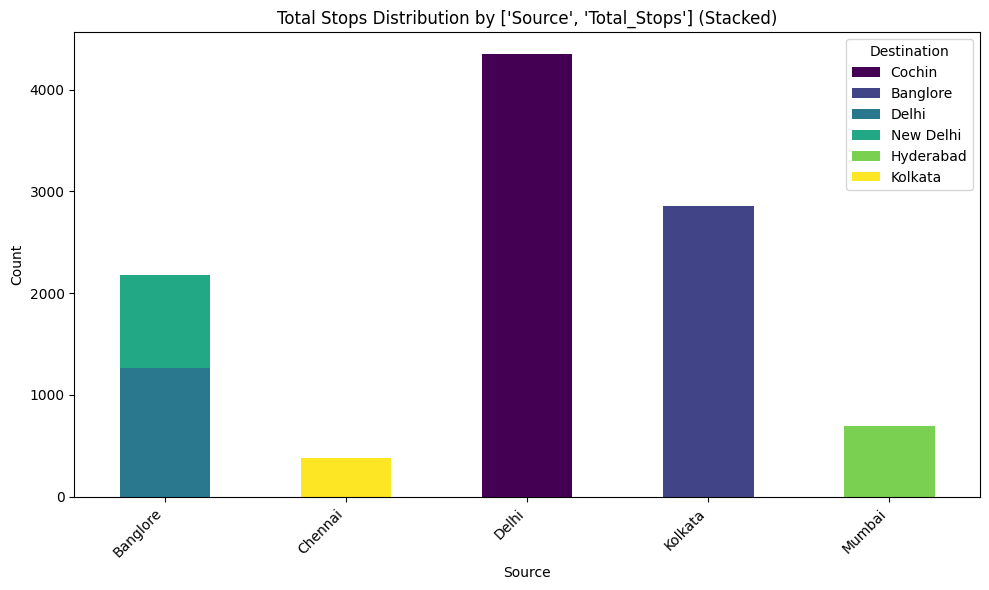

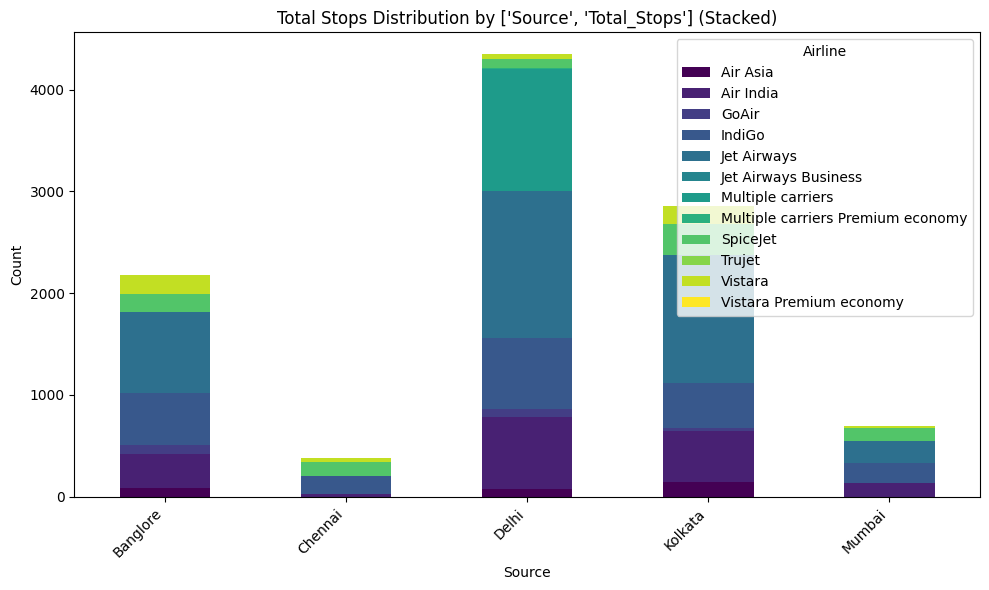

/tmp/ipykernel_23378/3749432221.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby([i, j]).size().unstack(fill_value=0)


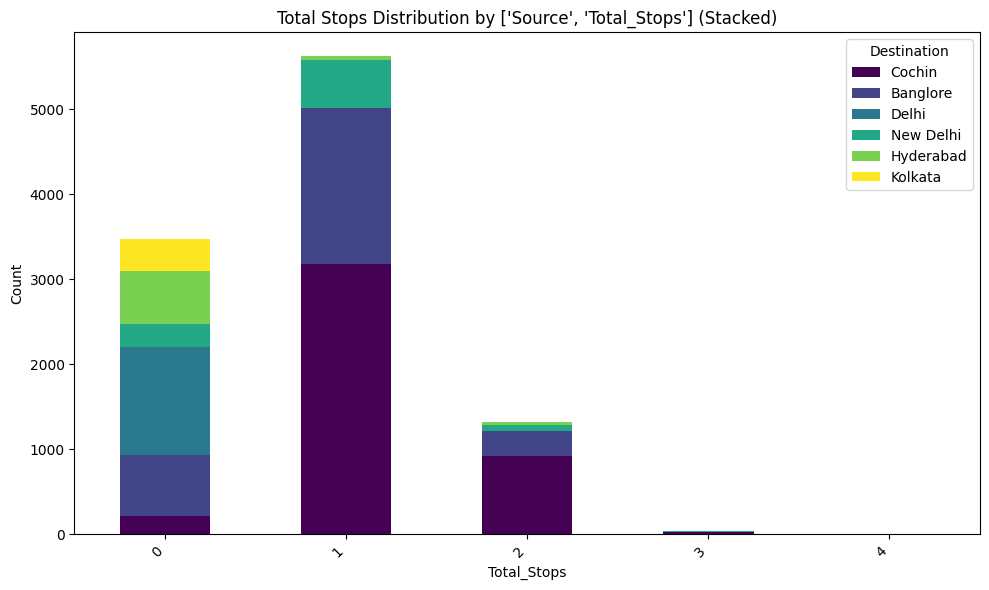

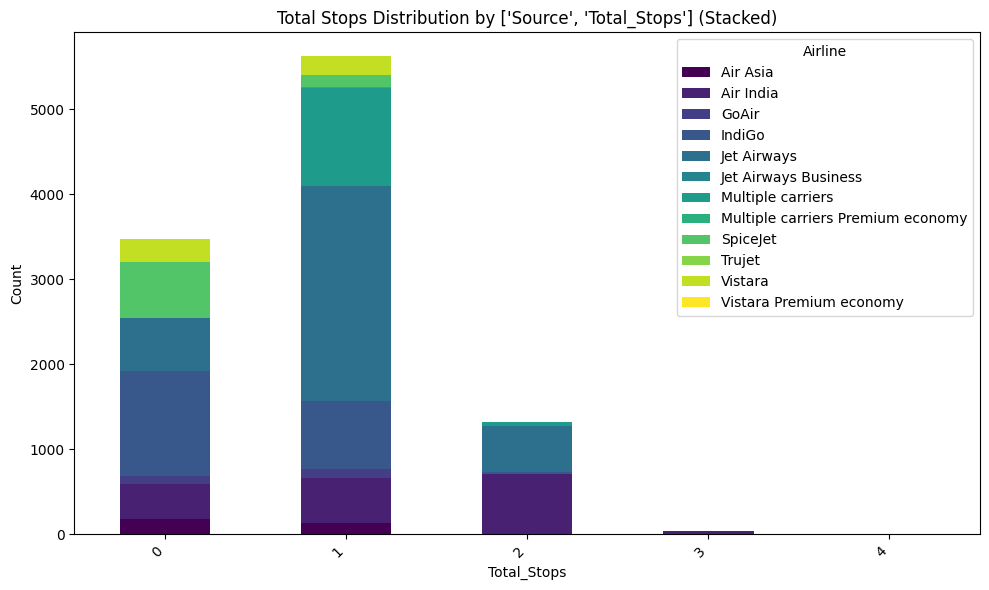

In [122]:
target1 = ['Source','Total_Stops']
target2 = ['Destination','Airline']
for i in target1:
  for j in target2:

    grouped_data = df.groupby([i, j]).size().unstack(fill_value=0)

    grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title(f'Total Stops Distribution by {target1} (Stacked)')
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=j)
    plt.tight_layout()
    plt.show()

# ***Model Training***

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [124]:
import re

def duration_to_minutes(duration_str):
    if pd.isna(duration_str) or not isinstance(duration_str, str):
        return 0 # Handle NaN or non-string values

    total_minutes = 0
    # Handle cases like '5m' or '2h'
    hours_match = re.search(r'(\d+)h', duration_str)
    minutes_match = re.search(r'(\d+)m', duration_str)

    if hours_match:
        total_minutes += int(hours_match.group(1)) * 60
    if minutes_match:
        total_minutes += int(minutes_match.group(1))
    return total_minutes

# Apply the conversion before splitting X and y
df['Duration_minutes'] = df['Duration'].apply(duration_to_minutes)


X = df[['Airline', 'Source', 'Destination', 'Total_Stops', 'Duration_minutes']]
y = df['Price']

# OUTLIER REMOVAL (IQR on Price)
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (y >= lower) & (y <= upper)

X = X[mask]
y = y[mask]

# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# COLUMN DEFINITIONS

ordinal_cols = ['Total_Stops']
nominal_cols = ['Airline', 'Source', 'Destination']
numeric_cols = ['Duration_minutes'] # Changed to the new numerical column


# PREPROCESSOR

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), ordinal_cols),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


# PIPELINE + MODEL

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])


# TRAIN MODEL

model.fit(X_train, y_train)


# EVALUATION

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.6033243277896275
MAE      : 1880.6165263139865
RMSE     : 2537.528451986723


## Summarized Insights

* Flights with more stops generally had higher ticket prices compared to non-stop flights.
* Flight duration had a strong impact on price. Thats why longer flights are comparatively more expensive.
* Ticket prices varied noticeably depending on source and destination routes, indicating route demand influences airfare.
* Flights departing during peak travel hours and busy months tended to have higher prices due to increased demand.
